예제 7.5 주가 예측

In [ ]:
# 예제 7.5 주가 예측

# finance-datareader 설치
!pip install finance-datareader

In [ ]:
# 셋업
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.utils import timeseries_dataset_from_array
import FinanceDataReader as fdr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 데이터셋 준비
df = fdr.DataReader('005930', '2010-01-01', '2023-12-31')   # 삼성전자

In [ ]:
# 상위 데이터 출력
df.head()

,Open,High,Low,Close,Volume,Change
Date,,,,,,
2010-01-04,16060,16180,16000,16180,239271,0.012516
2010-01-05,16520,16580,16300,16440,559219,0.016069
2010-01-06,16580,16820,16520,16820,459755,0.023114
2010-01-07,16820,16820,16260,16260,443237,-0.033294
2010-01-08,16400,16420,16120,16420,295798,0.009840


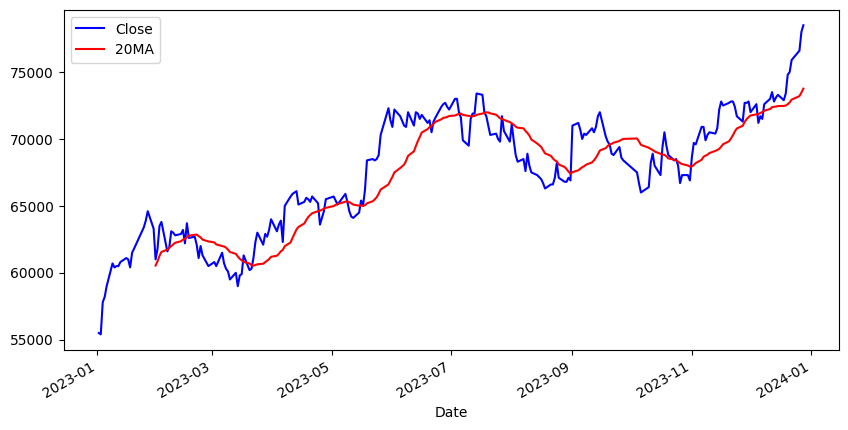

In [ ]:
# 주가/이동 평균선(20일)
sliced_df = df['2023-01-01':'2023-12-31']   # 구간 지정

plt.figure(figsize=(10, 5))

sliced_df['Close'].plot(color='blue', label='Close')
sliced_df['Close'].rolling(20).mean().plot(color='red', label='20MA')
plt.legend(loc='best')

plt.show()

In [ ]:
# mplfinance 설치
!pip install mplfinance

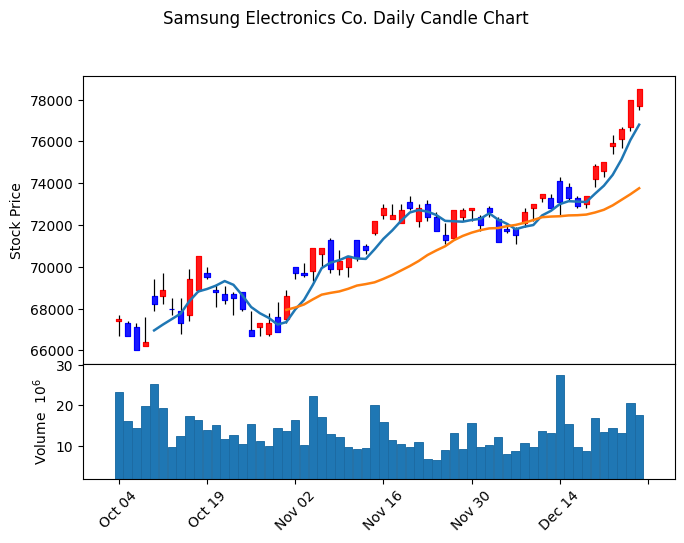

In [ ]:
# 일봉 차트
import mplfinance as mpf

candle_df = df['2023-10-01':'2023-12-31']

mc = mpf.make_marketcolors(up='red', down='blue', edge='inherit')
style = mpf.make_mpf_style(marketcolors=mc)

mpf.plot(candle_df,
         type='candle',      # 캔들 차트
         mav=(5, 20),        # 이동 평균선 5/20일
         volume=True,        # 거래량 표시
         style=style,        # 색상 지정
         figratio=(10, 7),   # 가로/세로 크기 지정
         title='Samsung Electronics Co. Daily Candle Chart',
         ylabel='Stock Price')

In [ ]:
# 하위 데이터 확인
df = df.drop('Change', axis=1)   # 불필요한 컬럼 제거

df.tail()

,Open,High,Low,Close,Volume
Date,,,,,
2023-12-21,74600,75000,74300,75000,13478766
2023-12-22,75800,76300,75400,75900,14515608
2023-12-26,76100,76700,75700,76600,13164909
2023-12-27,76700,78000,76500,78000,20651042
2023-12-28,77700,78500,77500,78500,17685672


In [ ]:
# 통계 확인
df.describe().loc[['count', 'mean', 'std', 'min', 'max']].round(2)

,Open,High,Low,Close,Volume
count,3453.00,3453.00,3453.00,3453.00,3453.00
mean,41056.53,41434.82,40660.10,41087.43,6418127.11
std,19779.08,19930.75,19615.35,19724.50,8966649.59
min,0.00,0.00,0.00,13600.00,0.00
max,90300.00,96800.00,89500.00,91000.00,90306177.00


In [ ]:
# 결측치(0) 확인
(df == 0).sum()

Open      3
High      3
Low       3
Close     0
Volume    3
dtype: int64

In [ ]:
# 결측치(0) 처리
df = df.replace(0, np.nan).fillna(df.mean()).astype(int)

In [ ]:
# 정규화
min = df.min()
max = df.max()

stock_df = (df - min) / (max - min)

In [ ]:
# 시퀀스 데이터셋 준비
sequence_length = 2                    # 2일간의 데이터 입력
offset = 1                             # 다음 날 주가 예측
shift = sequence_length + offset - 1   # 레이블 위치

train_ds = timeseries_dataset_from_array(   # 학습 데이터셋
    data=stock_df['2010-01':'2021-12'].to_numpy()[:-shift],
    targets=stock_df['Close']['2010-01':'2021-12'].to_numpy()[shift:],
    sequence_length=sequence_length,
    batch_size=32,
    shuffle=False)

valid_ds = timeseries_dataset_from_array(   # 검증 데이터셋
    data=stock_df['2022-01':'2022-12'].to_numpy()[:-shift],
    targets=stock_df['Close']['2022-01':'2022-12'].to_numpy()[shift:],
    sequence_length=sequence_length,
    batch_size=32,
    shuffle=False)

test_ds = timeseries_dataset_from_array(   # 테스트 데이터셋
    data=stock_df['2023-01':'2023-12'].to_numpy()[:-shift],
    targets=stock_df['Close']['2023-01':'2023-12'].to_numpy()[shift:],
    sequence_length=sequence_length,
    batch_size=32,
    shuffle=False)

for inputs, targets in train_ds.take(1):
  print(inputs.shape)    # 입력 shape 확인
  print(targets.shape)   # 레이블 shape 확인

(32, 2, 5)
(32,)


In [ ]:
# 모델 생성
inputs = Input(shape=(sequence_length, 5))    # 입력 특징 5개
x = LSTM(32, return_sequences=True)(inputs)   # 뉴런 수 32개
x = LSTM(32)(x)                               # 뉴런 수 32개
outputs = Dense(1)(x)                         # 출력층 뉴런 1개

model = Model(inputs=inputs, outputs=outputs)

model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 2, 5)]            0         
                                                                 
 lstm (LSTM)                 (None, 2, 32)             4864      
                                                                 
 lstm_1 (LSTM)               (None, 32)                8320      
                                                                 
 dense (Dense)               (None, 1)                 33        
                                                                 
Total params: 13217 (51.63 KB)
Trainable params: 13217 (51.63 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
# 모델 컴파일
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [ ]:
# 모델 학습
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',   # 모니터링 지표 지정
    patience=3)           # 허용 범위 지정

history = model.fit(train_ds, epochs=50, verbose=0,
                    validation_data=valid_ds,
                    callbacks=early_stopping)

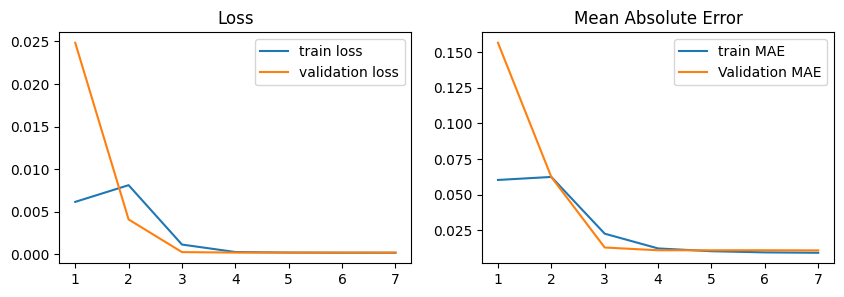

In [ ]:
# 학습 결과 시각화
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 3))

ax = axs[0]
ax.plot(range(1, len(history.history['loss']) + 1),
        history.history['loss'], label='train loss')
ax.plot(range(1, len(history.history['val_loss']) + 1),
        history.history['val_loss'], label='validation loss')
ax.set_title('Loss')
ax.legend(loc='best')

ax = axs[1]
ax.plot(range(1, len(history.history['mae']) + 1),
        history.history['mae'], label='train MAE')
ax.plot(range(1, len(history.history['val_mae']) + 1),
        history.history['val_mae'], label='Validation MAE')
ax.set_title('Mean Absolute Error')
ax.legend(loc='best')
plt.show()

In [ ]:
# 모델 평가
model.evaluate(test_ds)

8/8 [==============================] - 0s 6ms/step - loss: 2.2016e-04 - mae: 0.0116


[0.00022015529975760728, 0.011585657484829426]

In [ ]:
# 모델 예측
for inputs, targets in test_ds.take(1):
    pred = model.predict(inputs)

    max_C = df['Close'].max()   # 종가의 최대값
    min_C = df['Close'].min()   # 종가의 최소값

    print(np.array(targets[0]) * (max_C - min_C) + min_C)   # 원래의 종가
    print(pred[0] * (max_C - min_C) + min_C)                # 환산한 예측치

1/1 [==============================] - 1s 626ms/step
57800.00000000001
[55086.50252819]


8/8 [==============================] - 1s 4ms/step


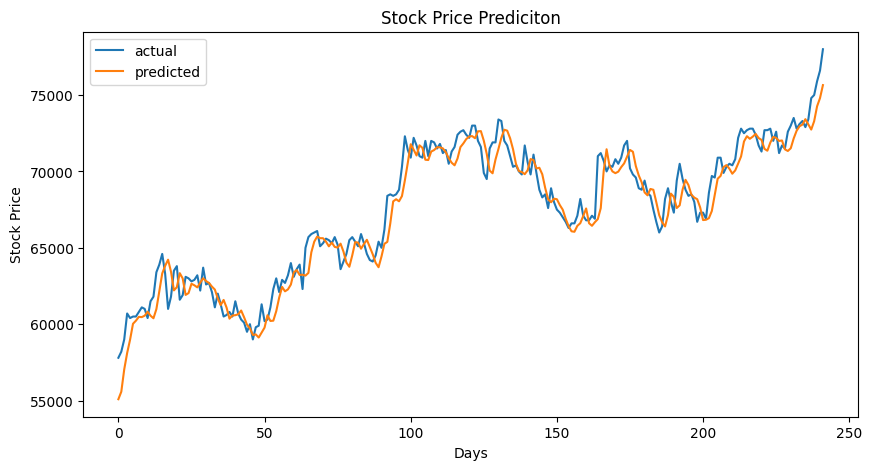

In [ ]:
# 예측 결과 시각화
y_pred = model.predict(test_ds)
y_pred = y_pred * (max_C - min_C) + min_C

y_test = []
for _, targets in test_ds:
    y_test.extend(targets)
y_test = np.array(y_test) * (max_C - min_C) + min_C

plt.figure(figsize=(10, 5))

plt.plot(y_test, label='actual')
plt.plot(y_pred, label='predicted')
plt.xlabel('Days')
plt.ylabel('Stock Price')
plt.title('Stock Price Prediciton')
plt.legend()

plt.show()